# TM10007 Machine Learning Group 10 Liver 

In [15]:
# Run this to use from colab environment
!pip install -q --upgrade git+https://github.com/jveenland/tm10007_ml.git

## Importing packages 


In [16]:
# General packages
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn import datasets as ds
import seaborn as sns

# Classifiers
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn import svm


# Statistics
from sklearn import model_selection
from sklearn import metrics
from sklearn import svm
from sklearn.svm import SVC
from sklearn.preprocessing import RobustScaler
from sklearn.model_selection import KFold, train_test_split, GridSearchCV, learning_curve
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score, roc_curve, confusion_matrix, ConfusionMatrixDisplay, auc
from scipy.stats import zscore, shapiro
from sklearn.pipeline import Pipeline

## Data loading 

Below are functions to load the dataset of your choice. After that, it is all up to you to create and evaluate a classification method. Beware, there may be missing values in these datasets. Good luck!

In [17]:
from worcliver.load_data import load_data

# Load the data
data = load_data()

# Replace the labels with binary labels
data_binary = data.copy()
data_binary["label"] = data_binary["label"].map({"malignant": 1, "benign": 0})

# Print number of samples and columns
print(f"The number of samples: {len(data_binary.index)}")
print(f"The number of columns: {len(data_binary.columns)}")
print(f"The number of malignant samples: {sum(data_binary['label']==1)}")
print(f"The number of benign samples: {sum(data_binary['label']==0)}")

The number of samples: 186
The number of columns: 494
The number of malignant samples: 94
The number of benign samples: 92


## Data preprocessing

In [18]:
# Checking for duplicate samples
duplicate_samples = data_binary[data_binary.duplicated()]
if len(duplicate_samples) > 0:
    print(f"Number of duplicate rows: {len(duplicate_samples)}")
else:
    print("No duplicate sample found.")   
# Remove duplicate samples
data_cleaned = data_binary.drop_duplicates()

# Checking for duplicate features
duplicate_features = data_cleaned.columns[data_cleaned.columns.duplicated()]
if len(duplicate_features) > 0:
    print(f"Number of duplicate features: {len(duplicate_features)}")
    print("Duplicate feature names:")
    print(list(duplicate_features))
    # Remove duplicate features
    data_cleaned = data_cleaned.loc[:, ~data_cleaned.columns.duplicated()]   
else:
    print("No duplicate features found.")

# Checking for missing data
# Check for infinite values
print(f"Amount of infinite data: {data_cleaned.map(np.isinf).sum().sum()}")
# Check for missing values
print(f"Amount of missing data: {data_cleaned.isna().sum().sum()}")


No duplicate sample found.
No duplicate features found.
Amount of infinite data: 0
Amount of missing data: 0


## Data splitting


In [19]:
# Split the dataset in features and labels
X = data_cleaned.drop(columns=["label"])
y = data_cleaned["label"]

# Split the dataset in train and test part
X_train, X_test, y_train, y_test = model_selection.train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Print the number of samples in the train and test set
print(f"The number of samples in the train set: {len(X_train.index)}")
print(f"The number of samples in the test set: {len(X_test.index)}")


The number of samples in the train set: 148
The number of samples in the test set: 38


## Scaling 
First check the distribution of the data, we check for normal and not normal distribution and we check the data on outliers

In [20]:
# Checking the distribution of the columns of the dataset and filling in missing values
alpha = 0.05
nd_columns_train = 0
nnd_columns_train = 0

for column in X_train:
    if X_train[column].min() != X_train[column].max():
        # Perform Shapiro-Wilk test for normality
        stat, p = shapiro(X_train[column].dropna())
        # Interpret the result
        if p > alpha:
            nd_columns_train += 1
            if X_train[column].isna().sum() > 0:
                # Fill missing values with the mean of the column
                X_train[column].fillna(X_train[column].mean(), inplace=True)
        else:
            nnd_columns_train += 1
            if X_train[column].isna().sum() > 0:
                # Fill missing values with the median of the column
                X_train[column].fillna(X_train[column].median(), inplace=True)
print(f"Number of normal distributed columns in the train set: {nd_columns_train}")
print(f"Number of non-normal distributed columns in the train set: {nnd_columns_train}")
    

Number of normal distributed columns in the train set: 53
Number of non-normal distributed columns in the train set: 423


In [21]:
# Calculating presence and number of outliers
columns_many_outliers_count = 0

for column in X_train:
    Q1 = X_train[column].quantile(0.25)
    Q3 = X_train[column].quantile(0.75)
    IQR = Q3 - Q1

    outliers = X_train[(X_train[column] < (Q1 - 1.5 * IQR)) | (X_train[column] > (Q3 + 1.5 * IQR))]
    outliers_count = outliers.shape[0]

    if outliers_count > 0.05 * X_train.shape[0]:
        columns_many_outliers_count += 1

perc_columns_many_outliers = (columns_many_outliers_count / len(X_train.columns)) * 100
print(f"Number of columns with many outliers: {columns_many_outliers_count}/{len(X_train.columns)} = {perc_columns_many_outliers:.2f}%")

Number of columns with many outliers: 166/493 = 33.67%


### Removing data with zero variance

In [22]:
from sklearn.feature_selection import VarianceThreshold

# Keep only numeric columns (if not already done)
X_train = X_train.select_dtypes(include=[np.number])
X_test = X_test.select_dtypes(include=[np.number])

# Only apply VarianceThreshold if any features have zero variance
zv_selector = VarianceThreshold(threshold=0)
zv_selector.fit(X_train)

support_mask = zv_selector.get_support()
n_removed = len(support_mask) - sum(support_mask)

if n_removed > 0:
    X_train = pd.DataFrame(zv_selector.transform(X_train), columns=X_train.columns[support_mask])
    X_test = pd.DataFrame(zv_selector.transform(X_test), columns=X_test.columns[support_mask])
    print(f"Number of features removed due to zero variance: {n_removed}")
else:
    print("No features with zero variance found — skipping removal.")


Number of features removed due to zero variance: 17


### Scaling the data

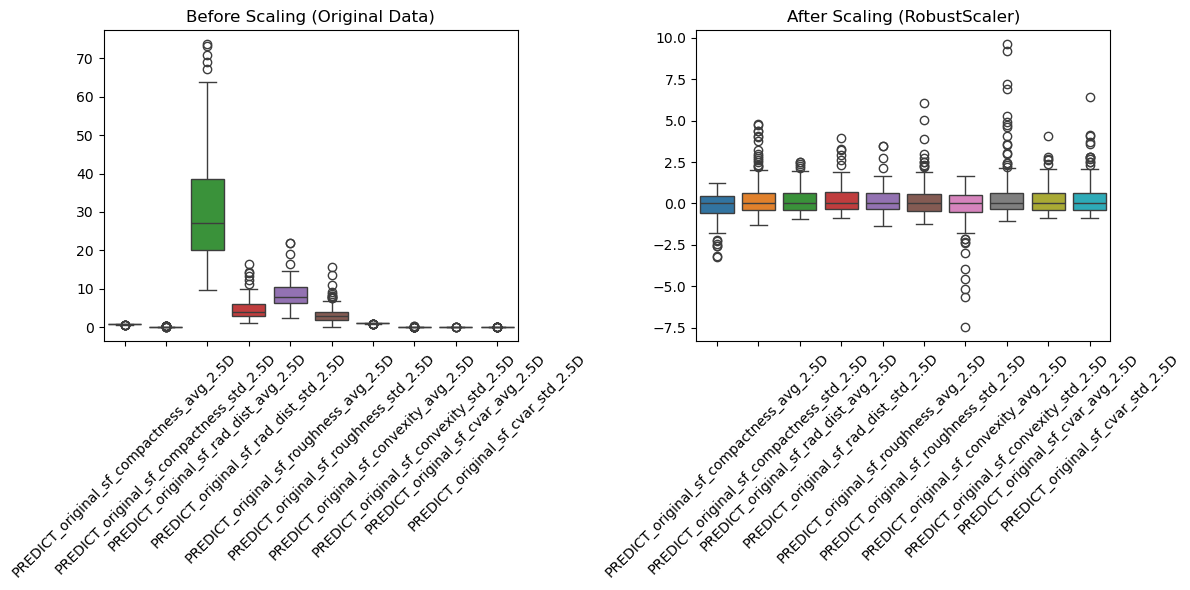

In [23]:
scaler = RobustScaler()
scaler.fit(X_train)

X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled = pd.DataFrame(X_test_scaled) 

features_to_plot = X_train.columns[:10] 
# Create a figure with two subplots
plt.figure(figsize=(12, 6))

# Plot original (unscaled) data
plt.subplot(1, 2, 1)
sns.boxplot(data=X_train[features_to_plot])
plt.title("Before Scaling (Original Data)")
plt.xticks(rotation=45)

# Plot scaled data
plt.subplot(1, 2, 2)
sns.boxplot(data=X_train_scaled[features_to_plot])
plt.title("After Scaling (RobustScaler)")
plt.xticks(rotation=45)

# Show the plot
plt.tight_layout()
plt.show()


### Feature selection


=== Evaluating with PCA ===

Model: kNN
  Avg accuracy: 0.582 | Recall: 0.587 | F1: 0.586

Model: SVM
  Avg accuracy: 0.500 | Recall: 0.613 | F1: 0.425

=== Evaluating with SelectKBest ===

Model: kNN
  Avg accuracy: 0.621 | Recall: 0.547 | F1: 0.590

Model: SVM
  Avg accuracy: 0.500 | Recall: 0.573 | F1: 0.415

=== Evaluating with GreedyForward ===

Model: kNN


c:\Users\anouk\anaconda3\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:111: UserWarning: Features [ 84  90 412 425 438] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
c:\Users\anouk\anaconda3\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:112: RuntimeWarning: invalid value encountered in divide
  f = msb / msw


  Avg accuracy: 0.547 | Recall: 0.533 | F1: 0.539

Model: SVM


c:\Users\anouk\anaconda3\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:111: UserWarning: Features [ 84  90 412 425 438] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
c:\Users\anouk\anaconda3\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:112: RuntimeWarning: invalid value encountered in divide
  f = msb / msw


  Avg accuracy: 0.709 | Recall: 0.707 | F1: 0.713


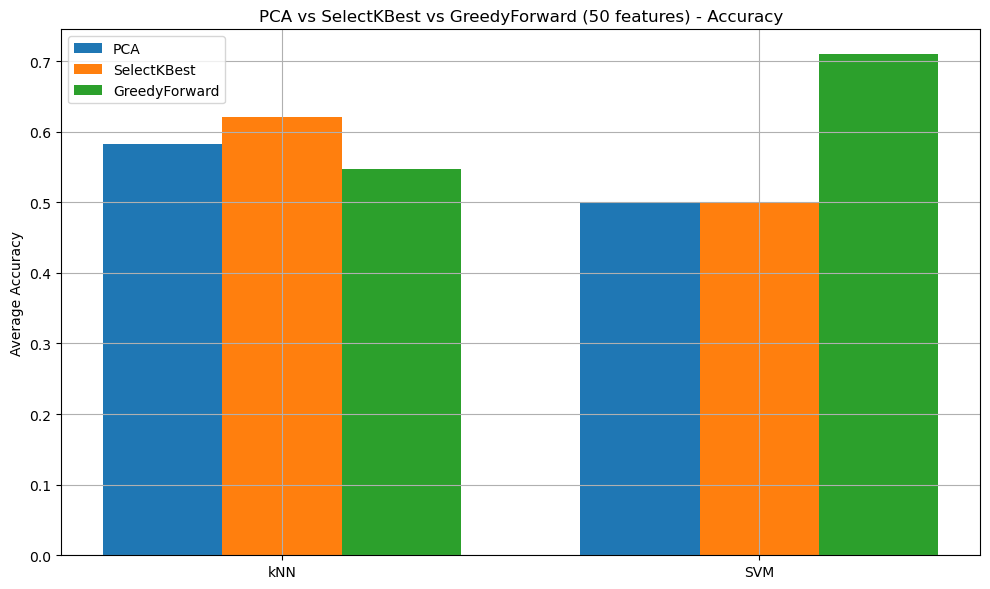

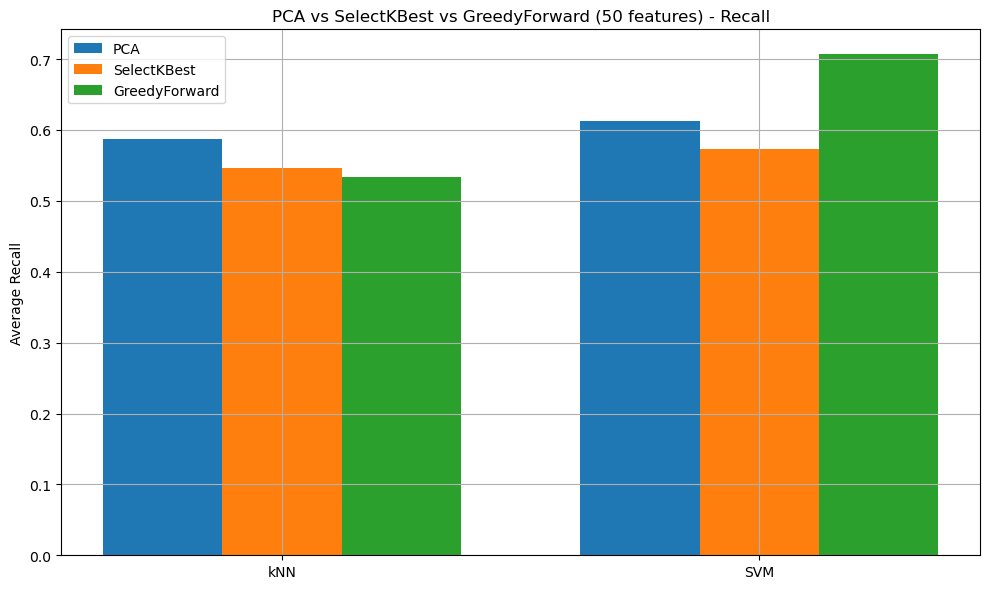

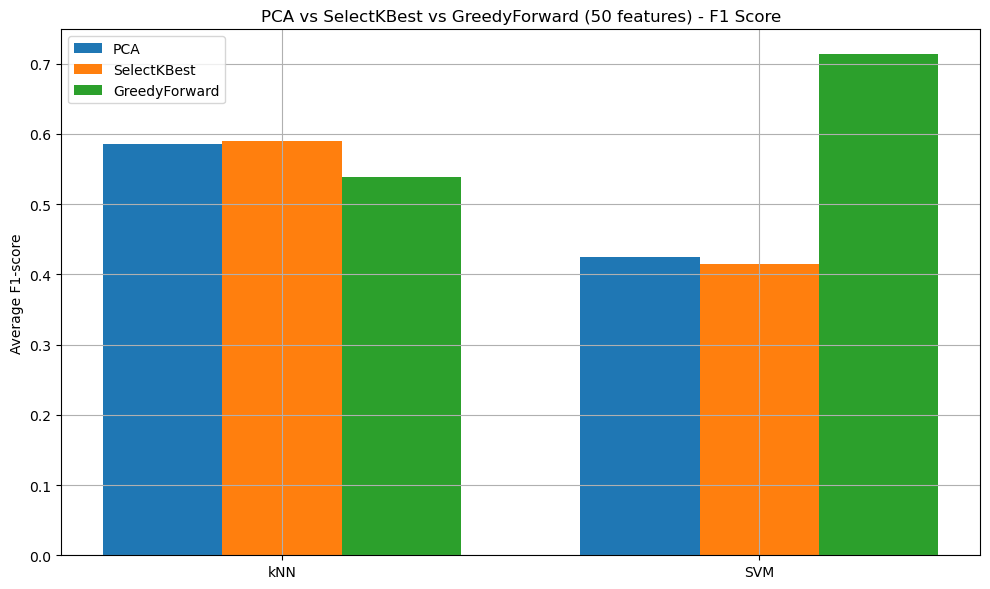

In [24]:
from sklearn.decomposition import PCA
from sklearn.feature_selection import SelectKBest, f_classif, mutual_info_classif
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, recall_score, f1_score
from sklearn.base import clone
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Models to test
models = {
    "kNN": KNeighborsClassifier(),
    "SVM": SVC(),
    #"RandomForest": RandomForestClassifier()
}

# Prepare StratifiedKFold
k = 50
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Storage for results
results = {}

# Loop over dimensionality reduction methods
for method_name in ["PCA", "SelectKBest", "GreedyForward"]:
    print(f"\n=== Evaluating with {method_name} ===")
    method_results = {}

    for model_name, model in models.items():
        print(f"\nModel: {model_name}")
        accuracies = []
        recalls = []
        f1s = []

        for train_idx, test_idx in kf.split(X_train_scaled, y_train):
            X_fold_train, X_fold_test = X_train_scaled.iloc[train_idx], X_train_scaled.iloc[test_idx]
            y_fold_train, y_fold_test = y_train.iloc[train_idx], y_train.iloc[test_idx]

            # Apply dimensionality reduction
            if method_name == "PCA":
                reducer = PCA(n_components=k)
                X_fold_train_reduced = reducer.fit_transform(X_fold_train, y_fold_train)
                X_fold_test_reduced = reducer.transform(X_fold_test)

            elif method_name == "SelectKBest":
                reducer = SelectKBest(mutual_info_classif, k=k)
                X_fold_train_reduced = reducer.fit_transform(X_fold_train, y_fold_train)
                X_fold_test_reduced = reducer.transform(X_fold_test)

            elif method_name == "GreedyForward":
                selector = SelectKBest(f_classif, k=k)
                X_fold_train_uni = selector.fit_transform(X_fold_train, y_fold_train)
                feature_names = X_fold_train.columns[selector.get_support()]
                X_fold_train_df = pd.DataFrame(X_fold_train_uni, columns=feature_names)

                selected_features = []
                remaining_features = list(feature_names)
                best_score = -np.inf
                patience = 2
                no_improve = 0

                while remaining_features and no_improve < patience:
                    local_best_score = -np.inf
                    local_best_feature = None

                    for feature in remaining_features:
                        trial_features = selected_features + [feature]
                        X_trial = X_fold_train_df[trial_features]
                        score = cross_val_score(clone(model), X_trial, y_fold_train,
                                                cv=3, scoring='accuracy').mean()
                        if score > local_best_score:
                            local_best_score = score
                            local_best_feature = feature

                    if local_best_score > best_score:
                        best_score = local_best_score
                        selected_features.append(local_best_feature)
                        remaining_features.remove(local_best_feature)
                        no_improve = 0
                    else:
                        no_improve += 1

                X_fold_train_reduced = X_fold_train_df[selected_features]
                X_fold_test_reduced = pd.DataFrame(
                    selector.transform(X_fold_test), columns=feature_names
                )[selected_features]

            model.fit(X_fold_train_reduced, y_fold_train)
            y_pred = model.predict(X_fold_test_reduced)

            acc = accuracy_score(y_fold_test, y_pred)
            recall = recall_score(y_fold_test, y_pred)
            f1 = f1_score(y_fold_test, y_pred)

            accuracies.append(acc)
            recalls.append(recall)
            f1s.append(f1)

        avg_acc = np.mean(accuracies)
        avg_recall = np.mean(recalls)
        avg_f1 = np.mean(f1s)

        print(f"  Avg accuracy: {avg_acc:.3f} | Recall: {avg_recall:.3f} | F1: {avg_f1:.3f}")
        method_results[model_name] = {
            "accuracy": avg_acc,
            "recall": avg_recall,
            "f1": avg_f1
        }

    results[method_name] = method_results

# === Plot comparison ===
labels = list(models.keys())
x = np.arange(len(labels))
width = 0.25

# Accuracy comparison
pca_scores = [results["PCA"][label]["accuracy"] for label in labels]
skb_scores = [results["SelectKBest"][label]["accuracy"] for label in labels]
greedy_scores = [results["GreedyForward"][label]["accuracy"] for label in labels]

plt.figure(figsize=(10, 6))
plt.bar(x - width, pca_scores, width, label='PCA')
plt.bar(x, skb_scores, width, label='SelectKBest')
plt.bar(x + width, greedy_scores, width, label='GreedyForward')
plt.ylabel('Average Accuracy')
plt.title(f'PCA vs SelectKBest vs GreedyForward ({k} features) - Accuracy')
plt.xticks(x, labels)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Recall comparison
pca_recall = [results["PCA"][label]["recall"] for label in labels]
skb_recall = [results["SelectKBest"][label]["recall"] for label in labels]
greedy_recall = [results["GreedyForward"][label]["recall"] for label in labels]

plt.figure(figsize=(10, 6))
plt.bar(x - width, pca_recall, width, label='PCA')
plt.bar(x, skb_recall, width, label='SelectKBest')
plt.bar(x + width, greedy_recall, width, label='GreedyForward')
plt.ylabel('Average Recall')
plt.title(f'PCA vs SelectKBest vs GreedyForward ({k} features) - Recall')
plt.xticks(x, labels)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# F1-score comparison
pca_f1 = [results["PCA"][label]["f1"] for label in labels]
skb_f1 = [results["SelectKBest"][label]["f1"] for label in labels]
greedy_f1 = [results["GreedyForward"][label]["f1"] for label in labels]

plt.figure(figsize=(10, 6))
plt.bar(x - width, pca_f1, width, label='PCA')
plt.bar(x, skb_f1, width, label='SelectKBest')
plt.bar(x + width, greedy_f1, width, label='GreedyForward')
plt.ylabel('Average F1-score')
plt.title(f'PCA vs SelectKBest vs GreedyForward ({k} features) - F1 Score')
plt.xticks(x, labels)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()



=== Evaluating PCA ===

Model: kNN

Model: SVM

=== Evaluating SelectKBest ===

Model: kNN


c:\Users\anouk\anaconda3\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:111: UserWarning: Features [ 84  90 412 425 438] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
c:\Users\anouk\anaconda3\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:112: RuntimeWarning: invalid value encountered in divide
  f = msb / msw
c:\Users\anouk\anaconda3\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:111: UserWarning: Features [ 84  90 412 425 438] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
c:\Users\anouk\anaconda3\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:112: RuntimeWarning: invalid value encountered in divide
  f = msb / msw
c:\Users\anouk\anaconda3\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:111: UserWarning: Features [ 84  90 412 425 438] are constant.
  warnings.warn("Features %s ar


Model: SVM


c:\Users\anouk\anaconda3\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:111: UserWarning: Features [ 84  90 412 425 438] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
c:\Users\anouk\anaconda3\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:112: RuntimeWarning: invalid value encountered in divide
  f = msb / msw
c:\Users\anouk\anaconda3\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:111: UserWarning: Features [ 84  90 412 425 438] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
c:\Users\anouk\anaconda3\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:112: RuntimeWarning: invalid value encountered in divide
  f = msb / msw
c:\Users\anouk\anaconda3\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:111: UserWarning: Features [ 84  90 412 425 438] are constant.
  warnings.warn("Features %s ar

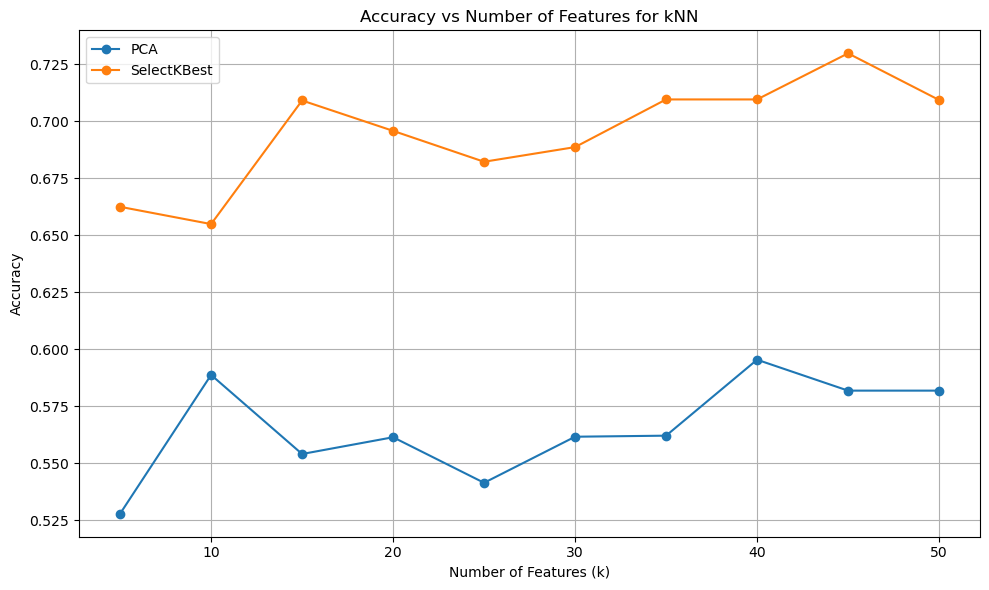

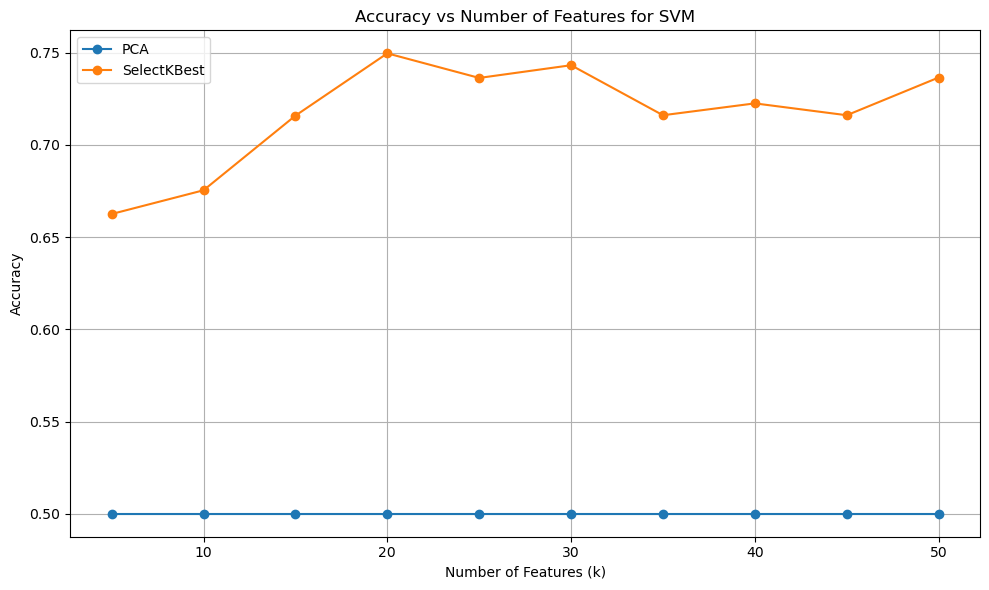

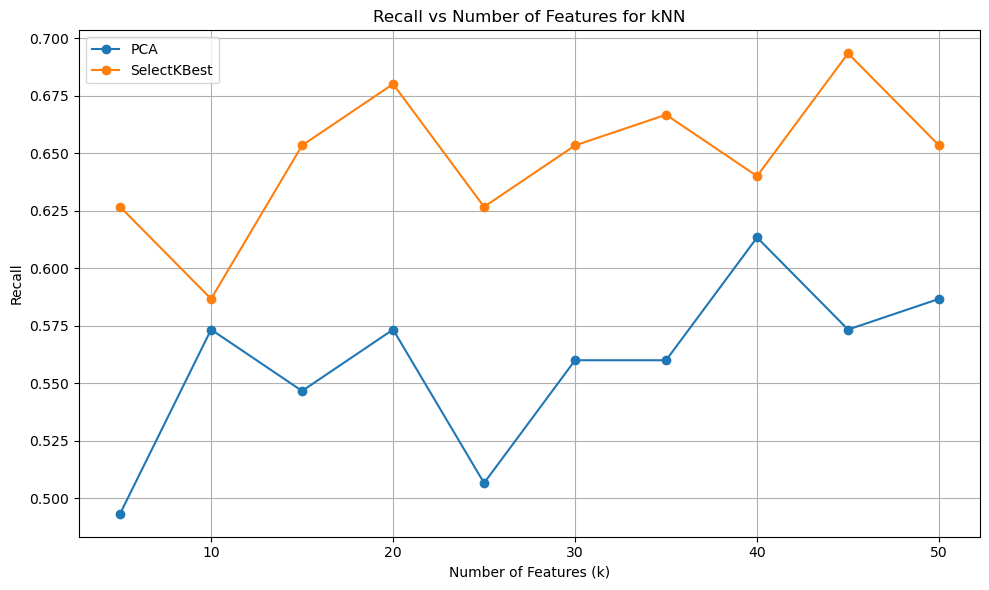

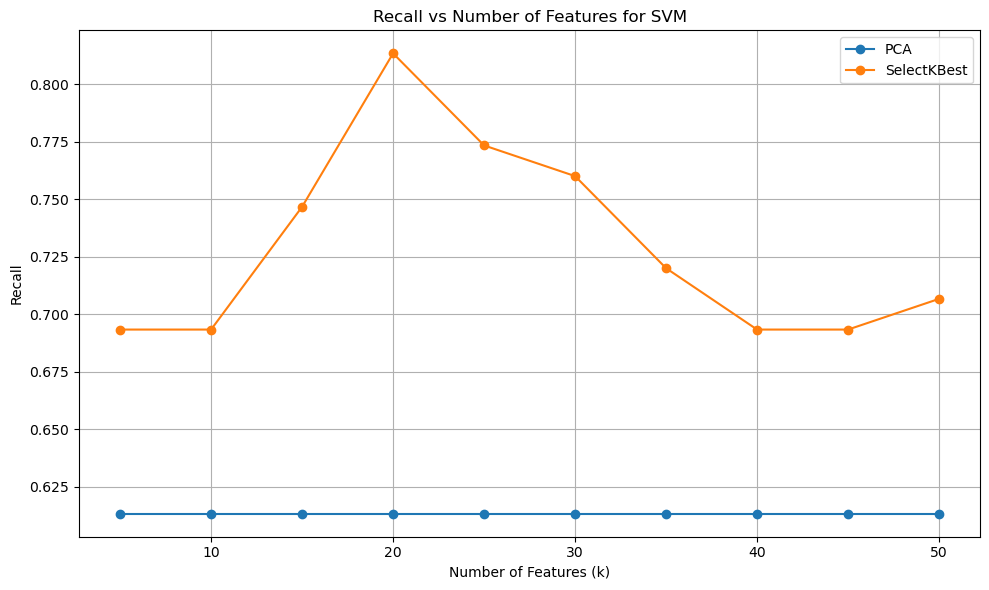

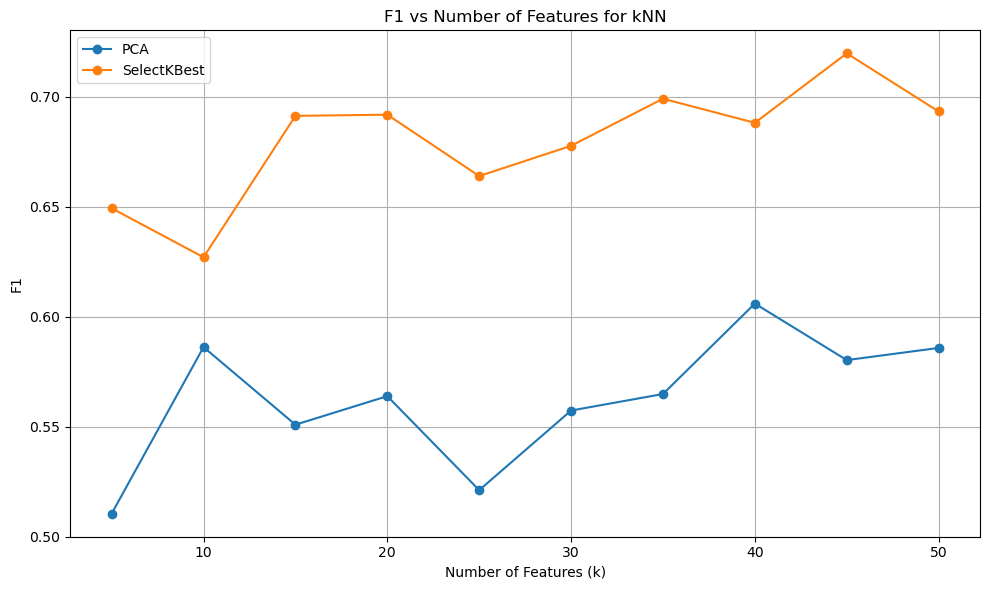

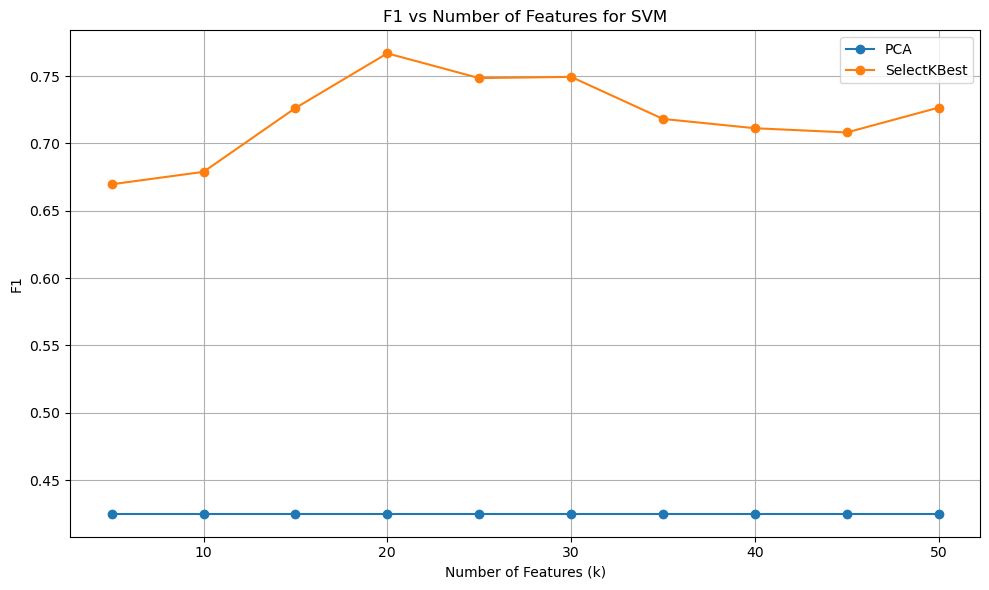

In [26]:
from sklearn.decomposition import PCA
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.model_selection import StratifiedKFold
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, recall_score, f1_score
from sklearn.base import clone
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Models to test
models = {
    "kNN": KNeighborsClassifier(),
    "SVM": SVC(),
}

kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
k_range = range(5, 55, 5)  # k = 5, 10, ..., 100

# Store results per method and model
results = {method: {model: {"k": [], "accuracy": [], "recall": [], "f1": []}
                    for model in models} for method in ["PCA", "SelectKBest"]}

for method_name in ["PCA", "SelectKBest"]:
    print(f"\n=== Evaluating {method_name} ===")

    for model_name, model in models.items():
        print(f"\nModel: {model_name}")

        for k in k_range:
            accuracies, recalls, f1s = [], [], []

            for train_idx, test_idx in kf.split(X_train_scaled, y_train):
                X_fold_train, X_fold_test = X_train_scaled.iloc[train_idx], X_train_scaled.iloc[test_idx]
                y_fold_train, y_fold_test = y_train.iloc[train_idx], y_train.iloc[test_idx]

                if method_name == "PCA":
                    reducer = PCA(n_components=k)
                    X_train_reduced = reducer.fit_transform(X_fold_train, y_fold_train)
                    X_test_reduced = reducer.transform(X_fold_test)

                elif method_name == "SelectKBest":
                    reducer = SelectKBest(f_classif, k=k)
                    X_train_reduced = reducer.fit_transform(X_fold_train, y_fold_train)
                    X_test_reduced = reducer.transform(X_fold_test)

                model_clone = clone(model)
                model_clone.fit(X_train_reduced, y_fold_train)
                y_pred = model_clone.predict(X_test_reduced)

                accuracies.append(accuracy_score(y_fold_test, y_pred))
                recalls.append(recall_score(y_fold_test, y_pred))
                f1s.append(f1_score(y_fold_test, y_pred))

            results[method_name][model_name]["k"].append(k)
            results[method_name][model_name]["accuracy"].append(np.mean(accuracies))
            results[method_name][model_name]["recall"].append(np.mean(recalls))
            results[method_name][model_name]["f1"].append(np.mean(f1s))

# === Plotting ===
for metric in ["accuracy", "recall", "f1"]:
    for model_name in models:
        plt.figure(figsize=(10, 6))
        for method in ["PCA", "SelectKBest"]:
            plt.plot(results[method][model_name]["k"], results[method][model_name][metric],
                     marker='o', label=method)
        plt.title(f"{metric.title()} vs Number of Features for {model_name}")
        plt.xlabel("Number of Features (k)")
        plt.ylabel(metric.title())
        plt.grid(True)
        plt.legend()
        plt.tight_layout()
        plt.show()



Evaluating kNN...


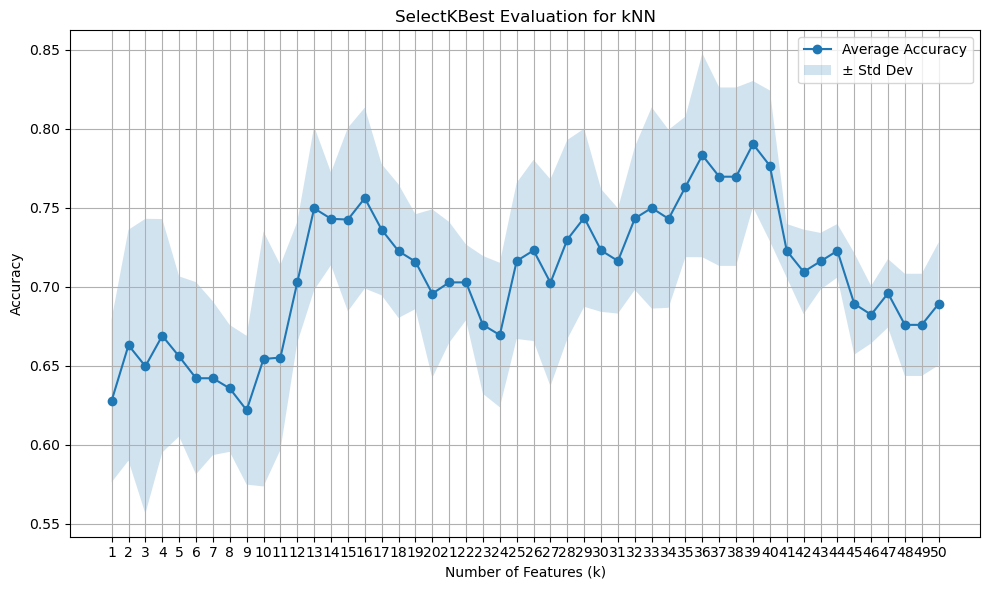


Evaluating SVM...


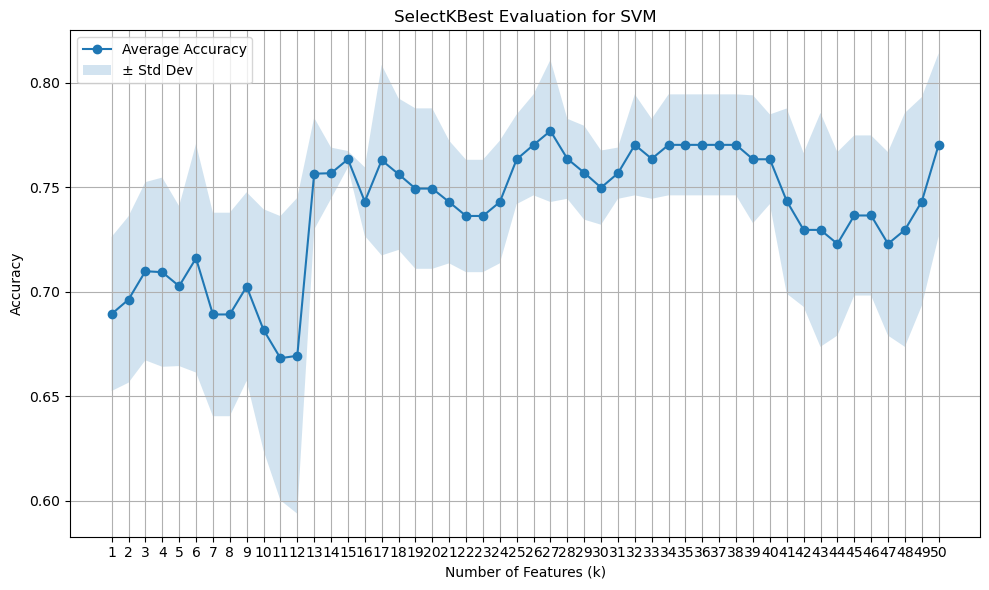

In [27]:
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.model_selection import StratifiedKFold
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
import numpy as np
import matplotlib.pyplot as plt

# Model dictionary
models = {
    "kNN": (KNeighborsClassifier(), X_train_scaled),
    "SVM": (SVC(kernel="rbf"), X_train_scaled),
    #"RandomForest": (RandomForestClassifier(), X_train)  # scaling not needed
}

k_values = range(1, 51)
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Result storage
results = {}

for model_name, (model, X_input) in models.items():
    print(f"\nEvaluating {model_name}...")
    average_accuracies = []
    std_accuracies = []

    for k in k_values:
        selector = SelectKBest(f_classif, k=k)
        X_selected = selector.fit_transform(X_input, y_train)
        accuracies = []

        for train_index, test_index in kf.split(X_selected, y_train):
            X_fold_train, X_fold_test = X_selected[train_index], X_selected[test_index]
            y_fold_train, y_fold_test = y_train.iloc[train_index], y_train.iloc[test_index]

            model.fit(X_fold_train, y_fold_train)
            y_pred = model.predict(X_fold_test)
            acc = accuracy_score(y_fold_test, y_pred)
            accuracies.append(acc)

        avg_acc = np.mean(accuracies)
        std_acc = np.std(accuracies)
        average_accuracies.append(avg_acc)
        std_accuracies.append(std_acc)

    # Save results for plotting
    results[model_name] = {
        "avg": average_accuracies,
        "std": std_accuracies
    }

    # Plot
    upper = np.array(average_accuracies) + np.array(std_accuracies)
    lower = np.array(average_accuracies) - np.array(std_accuracies)

    plt.figure(figsize=(10, 6))
    plt.plot(list(k_values), average_accuracies, marker='o', label='Average Accuracy')
    plt.fill_between(list(k_values), upper, lower, alpha=0.2, label='± Std Dev')
    plt.title(f'SelectKBest Evaluation for {model_name}')
    plt.xlabel('Number of Features (k)')
    plt.ylabel('Accuracy')
    plt.grid(True)
    plt.xticks(list(k_values))
    plt.legend()
    plt.tight_layout()
    plt.show()


#### Select k_best features per model


kNN → beste k = 39


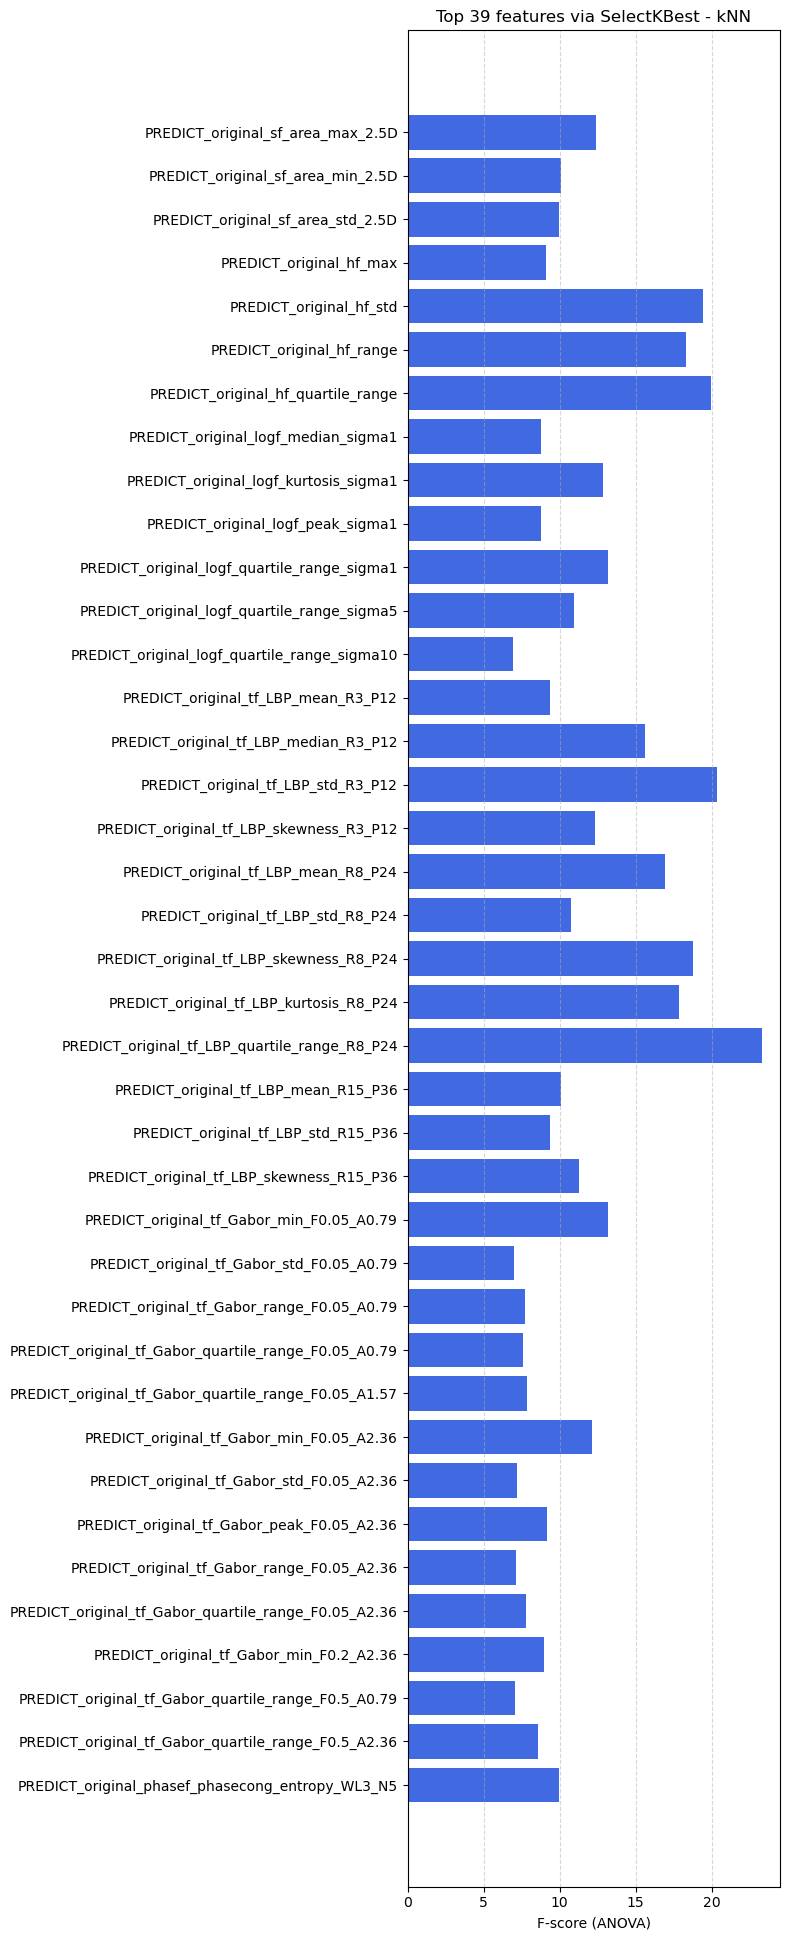

SVM → beste k = 27


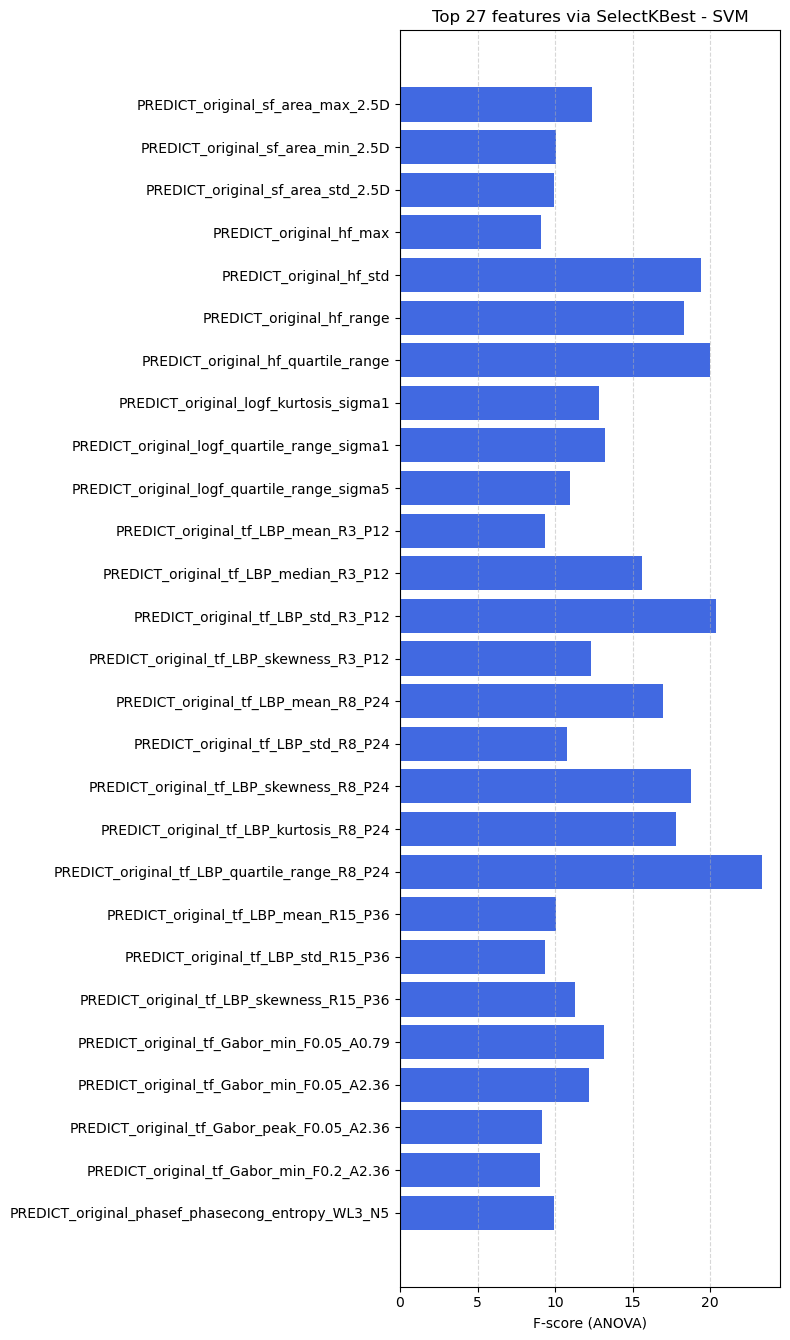

In [28]:
import matplotlib.pyplot as plt
from sklearn.feature_selection import SelectKBest, f_classif


for model_name, (models, X_input) in models.items():
    # Bepaal het beste k
    k_best = np.argmax(results[model_name]["avg"]) + 1
    print(f"{model_name} → beste k = {k_best}")

    # Pas SelectKBest toe
    selector = SelectKBest(score_func=f_classif, k=k_best)
    selector.fit(X_input, y_train)
    selected_feature_names = X_input.columns[selector.get_support()]
    f_scores = selector.scores_[selector.get_support()]

    # Maak plot
    plt.figure(figsize=(8, max(4, k_best * 0.5)))  # dynamische hoogte
    plt.barh(selected_feature_names, f_scores, color='royalblue')
    plt.xlabel("F-score (ANOVA)")
    plt.title(f"Top {k_best} features via SelectKBest - {model_name}")
    plt.gca().invert_yaxis()  # hoogste bovenaan
    plt.grid(True, axis='x', linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()


### feature selection with Greedy forward feature selection


=== kNN ===


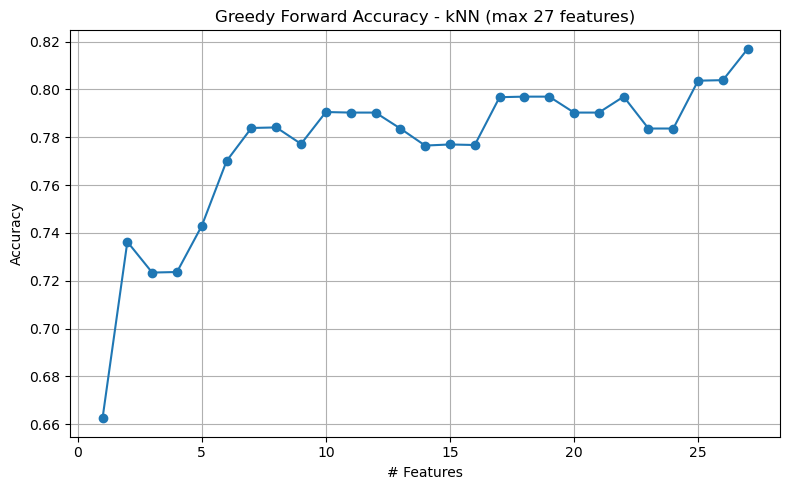


=== SVM ===


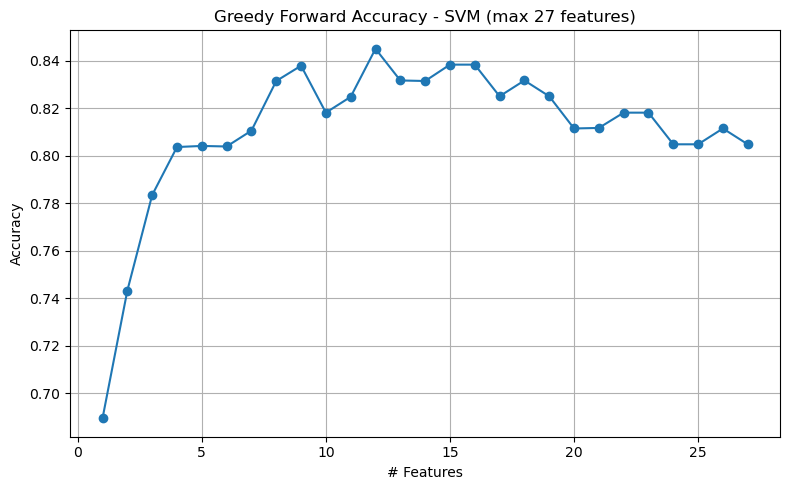


=== Samenvatting Vergelijking ===

kNN:
  k_best: 27
  Accuracy Univariate: 0.6892
  Accuracy Greedy:     0.8170
  # Greedy features:   27
  Overlap: 27 → ['PREDICT_original_tf_Gabor_min_F0.5_A2.36', 'PREDICT_original_logf_range_sigma5', 'PREDICT_original_tf_LBP_std_R3_P12', 'PREDICT_original_hf_range', 'PREDICT_original_logf_std_sigma5', 'PREDICT_original_tf_LBP_kurtosis_R15_P36', 'PREDICT_original_hf_quartile_range', 'PREDICT_original_tf_Gabor_min_F0.05_A2.36', 'PREDICT_original_tf_LBP_skewness_R3_P12', 'PREDICT_original_logf_quartile_range_sigma5', 'PREDICT_original_tf_LBP_skewness_R8_P24', 'PREDICT_original_tf_Gabor_min_F0.05_A0.79', 'PREDICT_original_tf_LBP_mean_R3_P12', 'PREDICT_original_tf_Gabor_quartile_range_F0.05_A2.36', 'PREDICT_original_hf_max', 'PREDICT_original_tf_Gabor_peak_F0.05_A2.36', 'PREDICT_original_hf_std', 'PREDICT_original_tf_Gabor_std_F0.05_A2.36', 'PREDICT_original_tf_Gabor_range_F0.05_A0.79', 'PREDICT_original_tf_LBP_quartile_range_R8_P24', 'PREDICT_original

In [13]:
# === Vergelijking SelectKBest (k_best) vs Greedy Forward Selection ===
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.base import clone
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# === Input per model (X-data per modeltype) ===
models = {
    "kNN": KNeighborsClassifier(),
    "SVM": SVC(kernel="rbf", probability=True),
    # "RandomForest": RandomForestClassifier()
}

X_input_map = {
    "kNN": X_train_scaled,
    "SVM": X_train_scaled,
    # "RandomForest": X_train
}

kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# results bevat eerder opgeslagen SelectKBest evaluatie met .avg voor elke k
# results = { "kNN": {"avg": [...]}, ... }

all_results = {}

for model_name, model in models.items():
    print(f"\n=== {model_name} ===")
    X_input = X_input_map[model_name]

    # Haal k_best op uit eerdere SelectKBest evaluatie
    #k_best = np.argmax(results[model_name]["avg"]) + 1

    # === Univariate selectie met k_best ===
    selector = SelectKBest(score_func=f_classif, k=50)
    X_uni_selected = selector.fit_transform(X_input, y_train)
    uni_features = X_input.columns[selector.get_support()]
    acc_uni = cross_val_score(clone(model), X_uni_selected, y_train, cv=kf, scoring='accuracy').mean()

    # === Greedy selectie op top-k_best univariate features ===
    X_reduced = pd.DataFrame(X_uni_selected, columns=uni_features)
    selected_features = []
    remaining = list(uni_features)
    scores = []

    for _ in range(k_best):
        best_score, best_feat = -np.inf, None
        for f in remaining:
            trial = selected_features + [f]
            X_trial = X_reduced[trial]
            score = cross_val_score(clone(model), X_trial, y_train, cv=kf, scoring='accuracy').mean()
            if score > best_score:
                best_score, best_feat = score, f

        if best_feat:
            selected_features.append(best_feat)
            remaining.remove(best_feat)
            scores.append(best_score)
        else:
            break

    acc_greedy = scores[-1] if scores else 0
    overlap = set(uni_features) & set(selected_features)

    # Opslaan
    all_results[model_name] = {
        "k_best": k_best,
        "acc_uni": acc_uni,
        "acc_greedy": acc_greedy,
        "selected_greedy": selected_features,
        "selected_univariate": list(uni_features),
        "overlap": list(overlap)
    }

    # === Plots ===
    plt.figure(figsize=(8, 5))
    plt.plot(range(1, len(scores)+1), scores, marker='o')
    plt.title(f"Greedy Forward Accuracy - {model_name} (max {k_best} features)")
    plt.xlabel("# Features")
    plt.ylabel("Accuracy")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# === Samenvatting ===
print("\n=== Samenvatting Vergelijking ===")
for model, res in all_results.items():
    print(f"\n{model}:")
    print(f"  k_best: {res['k_best']}")
    print(f"  Accuracy Univariate: {res['acc_uni']:.4f}")
    print(f"  Accuracy Greedy:     {res['acc_greedy']:.4f}")
    print(f"  # Greedy features:   {len(res['selected_greedy'])}")
    print(f"  Overlap: {len(res['overlap'])} → {res['overlap']}")
